# Relacion 4

### Ejercicio 6: Realizar el ejercicio 6 del tema 4 de Marc Baldo


In [2]:
### Librerías ######

import numpy as np
import matplotlib.pyplot as plt

In [3]:
#### Constantesss ######

hbar = 6.582*10**(-16)     #eV*s

q = 1.602*10**(-19)         #C

kbtz = 8.617*10**(-5)       #eV/K cte de boltzmann 

In [4]:
##### Variables ##############

mu_S = 1.0
mu_D = 0.4

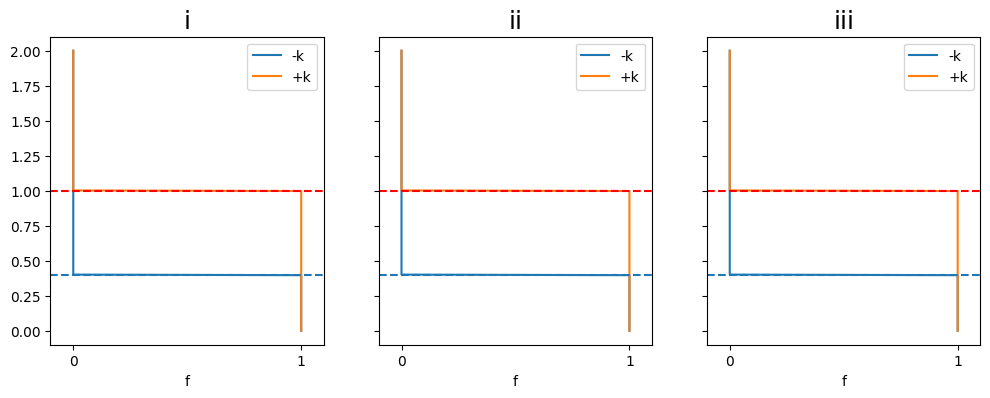

In [ ]:
### Código para hacer el apartado a del ejercicio 4.6 #################

#Creo mi espacio de energías
E = np.linspace(0, 2, 500)  #Lo pongo hasta 2 por si acaso

#Creo la filling function para el apartado a, con T=1 solo es o 1 o 0 porque no hay scattering

f_plus = np.where(E < mu_S, 1, 0)   # +k se llena hasta mu_s
f_minus = np.where(E < mu_D, 1, 0)  # -k se llena hasta mu_d


#Lo ploteamos

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
titles = ['i', 'ii', 'iii']

for ax, title in zip(axes, titles):
    ax.plot(f_minus, E, label='-k')
    ax.plot(f_plus, E, label='+k')

    ax.axhline(mu_S, linestyle='--', color='red')
    ax.axhline(mu_D, linestyle='--')

    ax.set_title(title, fontsize=18)    
    ax.set_xlabel('f')
    ax.set_xlim(-0.1, 1.1)      #Le tengo que poner esto porque sino no se ve
    ax.set_xticks([0, 1])
    ax.legend()

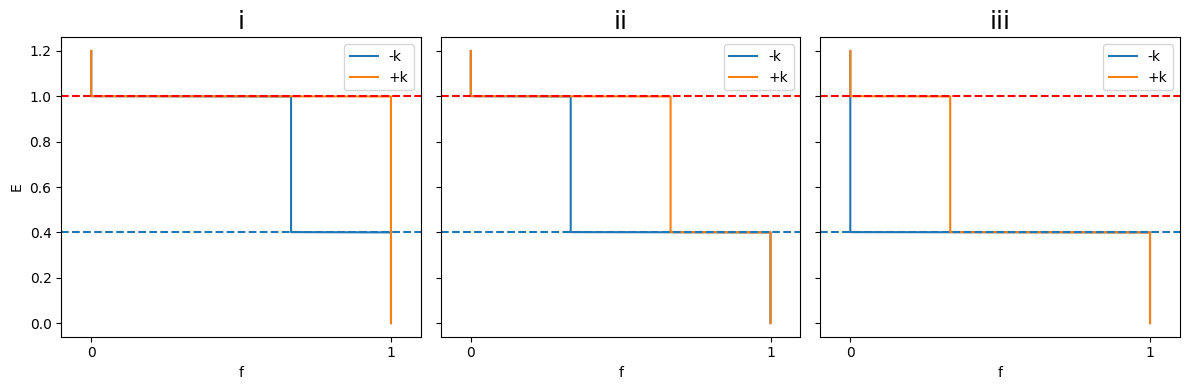

In [15]:
T = 0.5              # Ponemos la transimisión de cada uno de los scattering sites
R = 1 - T

#Ponemos las funciones de cada sitio. Le llamo window al intervalo, y plus y minus pues para las k

f_i_plus_window   = 1.0
f_i_minus_window  = 2*(1 - T)/(2 - T)

f_ii_plus_window  = 1/(2 - T)
f_ii_minus_window = (1 - T)/(2 - T)

f_iii_plus_window  = T/(2 - T)
f_iii_minus_window = 0.0


#Ahora hacemos ela función para luego dar valores.

def filling(E, mu_D, mu_S, f_window):
    f = np.zeros_like(E)
    f[E < mu_D] = 1.0
    f[(E >= mu_D) & (E <= mu_S)] = f_window
    f[E > mu_S] = 0.0
    return f

#Ahora si, damos valores Filling functions
f_i_plus   = filling(E, mu_D, mu_S, f_i_plus_window)
f_i_minus  = filling(E, mu_D, mu_S, f_i_minus_window)

f_ii_plus  = filling(E, mu_D, mu_S, f_ii_plus_window)
f_ii_minus = filling(E, mu_D, mu_S, f_ii_minus_window)

f_iii_plus  = filling(E, mu_D, mu_S, f_iii_plus_window)
f_iii_minus = filling(E, mu_D, mu_S, f_iii_minus_window)


#Ploteo cada región y cada línea

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

datos = [
    ("i",   f_i_minus,   f_i_plus),
    ("ii",  f_ii_minus,  f_ii_plus),
    ("iii", f_iii_minus, f_iii_plus)
]

for ax, (titulo, f_minus, f_plus) in zip(axes, datos):
    ax.plot(f_minus, E, label='-k')
    ax.plot(f_plus, E, label='+k')

    ax.axhline(mu_S, linestyle='--', color='red')
    ax.axhline(mu_D, linestyle='--')

    ax.set_title(titulo, fontsize=18)
    ax.set_xlabel('f')
    ax.set_xlim(-0.1, 1.1)
    ax.set_xticks([0, 1])
    ax.legend()

axes[0].set_ylabel('E')

plt.tight_layout()
plt.show()